# Embeddings Avanzados: FastText y Sentence-BERT

**Continuación de:** *Embeddings en Procesamiento del Lenguaje Natural*

## Contenido
1. [FastText: Word2Vec con subpalabras](#1)
2. [Sentence-BERT: embeddings contextuales de frases](#2)
3. [Chatbot Q&A con búsqueda semántica](#3)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from gensim.models import FastText, Word2Vec
from sentence_transformers import SentenceTransformer
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (11, 7)
plt.rcParams['font.size'] = 12
print('Todo importado correctamente.')

c:\Users\igome\miniconda3\envs\AIAerospace\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Todo importado correctamente.


<a id='1'></a>
## 1. FastText: Word2Vec con subpalabras

### 1.1 El problema que resuelve FastText

Word2Vec asigna un vector a **cada palabra completa** del vocabulario.  
Si aparece una palabra nueva en inferencia → error **OOV** (Out-Of-Vocabulary).

**FastText** (Bojanowski et al., 2017 — Facebook AI) descompone cada palabra en  
*n-gramas de caracteres*. El vector final es el promedio de todos sus n-gramas.

$$\vec{w} = \frac{1}{|G_w|} \sum_{g \in G_w} \vec{z}_g$$

donde $G_w$ es el conjunto de n-gramas de la palabra $w$.

In [2]:
def ngramas_caracteres(palabra, min_n=3, max_n=6):
    """Genera n-gramas de caracteres como los usa FastText."""
    token = f'<{palabra}>'
    ngramas = set()
    for n in range(min_n, max_n + 1):
        for i in range(len(token) - n + 1):
            ngramas.add(token[i:i+n])
    return sorted(ngramas)

# Ejemplo con palabras del dominio aeronáutico
palabras_ejemplo = ['aterrizar', 'aterrizaje', 'aterrizando', 'despegar',
                    'despegue', 'avión', 'aviones', 'aviación']

print('Descomposición en n-gramas de caracteres (min=3, max=6):')
print('=' * 70)
for p in palabras_ejemplo:
    ngs = ngramas_caracteres(p)
    print(f'  {p:<20} → {len(ngs):>2} n-gramas: {ngs[:6]}...')

Descomposición en n-gramas de caracteres (min=3, max=6):
  aterrizar            → 30 n-gramas: ['<at', '<ate', '<ater', '<aterr', 'ar>', 'ate']...
  aterrizaje           → 34 n-gramas: ['<at', '<ate', '<ater', '<aterr', 'aje', 'aje>']...
  aterrizando          → 38 n-gramas: ['<at', '<ate', '<ater', '<aterr', 'and', 'ando']...
  despegar             → 26 n-gramas: ['<de', '<des', '<desp', '<despe', 'ar>', 'des']...
  despegue             → 26 n-gramas: ['<de', '<des', '<desp', '<despe', 'des', 'desp']...
  avión                → 14 n-gramas: ['<av', '<avi', '<avió', '<avión', 'avi', 'avió']...
  aviones              → 22 n-gramas: ['<av', '<avi', '<avio', '<avion', 'avi', 'avio']...
  aviación             → 26 n-gramas: ['<av', '<avi', '<avia', '<aviac', 'aci', 'ació']...


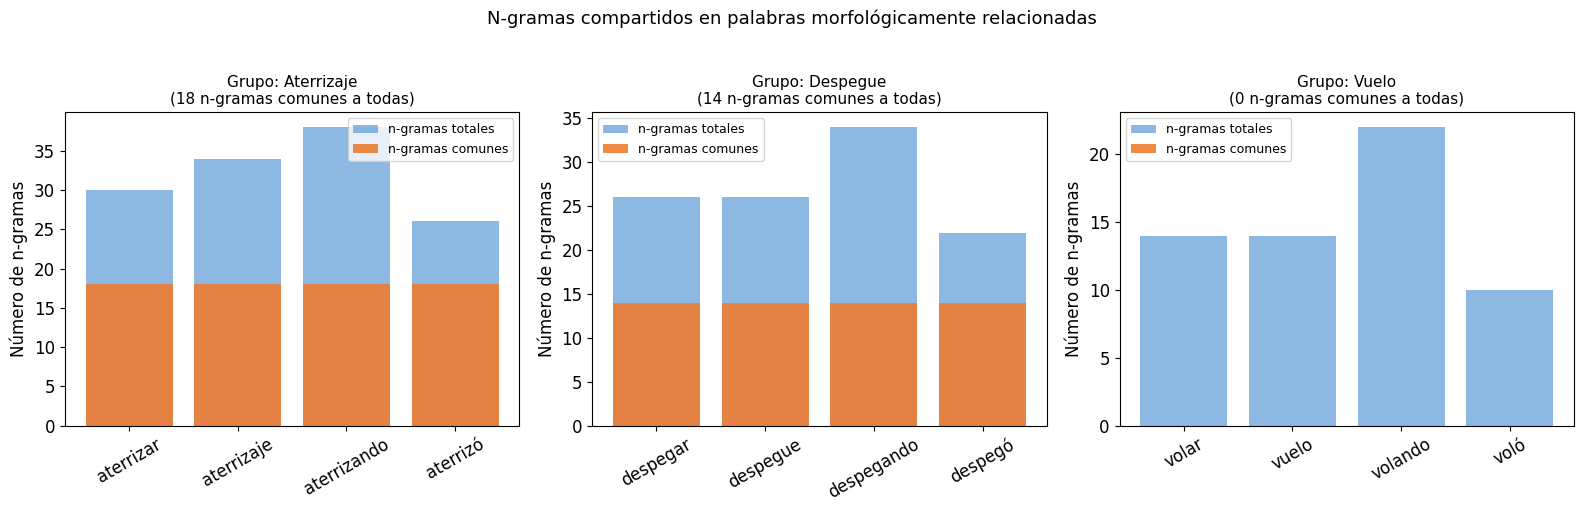


Esto hace que palabras morfológicamente relacionadas tengan vectores parecidos.
Word2Vec las trataría como palabras completamente independientes.


In [3]:
# Visualizar n-gramas compartidos entre palabras morfológicamente relacionadas
grupos = {
    'Aterrizaje': ['aterrizar', 'aterrizaje', 'aterrizando', 'aterrizó'],
    'Despegue':   ['despegar', 'despegue', 'despegando', 'despegó'],
    'Vuelo':      ['volar', 'vuelo', 'volando', 'voló'],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (grupo, palabras) in zip(axes, grupos.items()):
    # N-gramas únicos por palabra (compartidos se ven como solapamiento)
    sets = [set(ngramas_caracteres(p)) for p in palabras]
    comun = sets[0].intersection(*sets[1:])
    conteos = [len(s) for s in sets]
    n_comun = [len(s & comun) for s in sets]
    
    bars = ax.bar(palabras, conteos, color='#5b9bd5', alpha=0.7, label='n-gramas totales')
    ax.bar(palabras, n_comun, color='#ed7d31', alpha=0.9, label='n-gramas comunes')
    ax.set_title(f'Grupo: {grupo}\n({len(comun)} n-gramas comunes a todas)', fontsize=11)
    ax.set_ylabel('Número de n-gramas')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.suptitle('N-gramas compartidos en palabras morfológicamente relacionadas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print('\nEsto hace que palabras morfológicamente relacionadas tengan vectores parecidos.')
print('Word2Vec las trataría como palabras completamente independientes.')

### 1.2 Entrenamiento del modelo FastText

In [4]:
# Corpus extendido con variaciones morfológicas
corpus = [
    "el avión despega del aeropuerto en condiciones meteorológicas adversas",
    "el avión aterriza en la pista mojada con viento cruzado",
    "los aviones comerciales transportan millones de pasajeros cada año",
    "la aviación comercial ha revolucionado el transporte mundial",
    "el piloto realiza el procedimiento de aterrizaje con visibilidad reducida",
    "el copiloto supervisa los instrumentos durante el despegue",
    "el aterrizaje automático se activa en condiciones de niebla densa",
    "el despegue se pospone por turbulencias en la zona de salida",
    "los pilotos entrenan en simuladores de vuelo avanzados",
    "el controlador aéreo gestiona el tráfico en el espacio aéreo",
    "el radar de aproximación guía el aterrizaje instrumental",
    "el motor turbofán proporciona empuje durante el vuelo crucero",
    "los motores se revisan antes de cada vuelo programado",
    "el combustible de aviación se carga con precisión antes del despegue",
    "el sistema de navegación inercial calcula la posición del avión",
    "la meteorología aeronáutica predice turbulencias en ruta",
    "el cohete lanza el satélite a órbita geoestacionaria",
    "la nave espacial regresa a la atmósfera después de la misión orbital",
    "el astronauta realiza una caminata espacial para reparar el satélite",
    "el lanzamiento del cohete se retrasa por condiciones meteorológicas",
    "el satélite de comunicaciones orbita sobre el ecuador terrestre",
    "el helicóptero realiza operaciones de búsqueda y rescate",
    "el dron autónomo realiza inspecciones de infraestructura",
    "el ingeniero aeronáutico diseña el fuselaje del nuevo avión",
    "la aerodinámica del ala determina la eficiencia en vuelo",
    "el sistema de piloto automático mantiene la altitud y rumbo",
    "el altímetro barométrico mide la presión atmosférica para calcular altitud",
    "el velocímetro indica la velocidad aerodinámica del avión en nudos",
    "la tormenta eléctrica genera turbulencias severas en vuelo",
    "la niebla reduce la visibilidad en el aeropuerto al mínimo operativo",
    "el hielo en las alas afecta la sustentación aerodinámica",
    "el sistema antihielo protege las superficies críticas del avión",
    "la comunicación por radio VHF conecta el piloto con la torre de control",
    "el transponder emite señales de identificación para el radar de control",
    "el sistema TCAS alerta de tráfico aéreo próximo al avión",
]

sentences = [frase.lower().split() for frase in corpus]
vocab_total = set(w for s in sentences for w in s)
print(f'Frases: {len(sentences)} | Vocabulario: {len(vocab_total)} palabras')

Frases: 35 | Vocabulario: 173 palabras


In [5]:
# Entrenar FastText con Gensim
modelo_ft = FastText(
    sentences=sentences,
    vector_size=50,
    window=4,
    min_count=1,
    workers=4,
    sg=1,          # Skip-gram
    min_n=3,       # n-grama mínimo
    max_n=6,       # n-grama máximo
    epochs=200,
    seed=42
)

# Entrenar también Word2Vec para comparar
modelo_w2v = Word2Vec(
    sentences=sentences,
    vector_size=50,
    window=4,
    min_count=1,
    workers=4,
    sg=1,
    epochs=200,
    seed=42
)

print(f'FastText  → vocabulario: {len(modelo_ft.wv)} palabras')
print(f'Word2Vec  → vocabulario: {len(modelo_w2v.wv)} palabras')

FastText  → vocabulario: 173 palabras
Word2Vec  → vocabulario: 173 palabras


### 1.3 FastText vs Word2Vec: palabras OOV

In [6]:
# Palabras que NO están en el corpus de entrenamiento
palabras_oov = [
    'aterrizamos',      # flexión verbal no vista
    'despegando',       # gerundio no visto
    'avioneta',         # derivada de "avión"
    'aeronavegación',   # compuesta con raíces conocidas
    'eVTOL',            # neologismo
    'supersónico',      # no en corpus
]

print('Manejo de palabras OOV (Out-Of-Vocabulary):')
print(f'{"Palabra":<22} {"en W2V":<10} {"en FastText":<14} {"Vector FT (5 dims)"}')
print('-' * 75)
for p in palabras_oov:
    en_w2v = p.lower() in modelo_w2v.wv
    en_ft  = p.lower() in modelo_ft.wv
    try:
        vec = modelo_ft.wv[p.lower()][:5]
        vec_str = np.array2string(vec, precision=3, suppress_small=True)
    except:
        vec_str = 'N/A'
    print(f'{p:<22} {str(en_w2v):<10} {str(en_ft):<14} {vec_str}')

print()
print('FastText genera vectores para CUALQUIER palabra mediante sus n-gramas,')
print('aunque nunca la haya visto durante el entrenamiento.')

Manejo de palabras OOV (Out-Of-Vocabulary):
Palabra                en W2V     en FastText    Vector FT (5 dims)
---------------------------------------------------------------------------
aterrizamos            False      True           [ 0.042 -0.214 -0.218  0.083  0.14 ]
despegando             False      True           [ 0.005 -0.16  -0.273 -0.054  0.084]
avioneta               False      True           [-0.006 -0.321 -0.159 -0.005  0.027]
aeronavegación         False      True           [-0.009 -0.196 -0.335 -0.063  0.211]
eVTOL                  False      True           [ 0.01  -0.012 -0.012  0.002  0.017]
supersónico            False      True           [ 0.065 -0.138 -0.133  0.03   0.047]

FastText genera vectores para CUALQUIER palabra mediante sus n-gramas,
aunque nunca la haya visto durante el entrenamiento.


### 1.4 Similitud morfológica con FastText

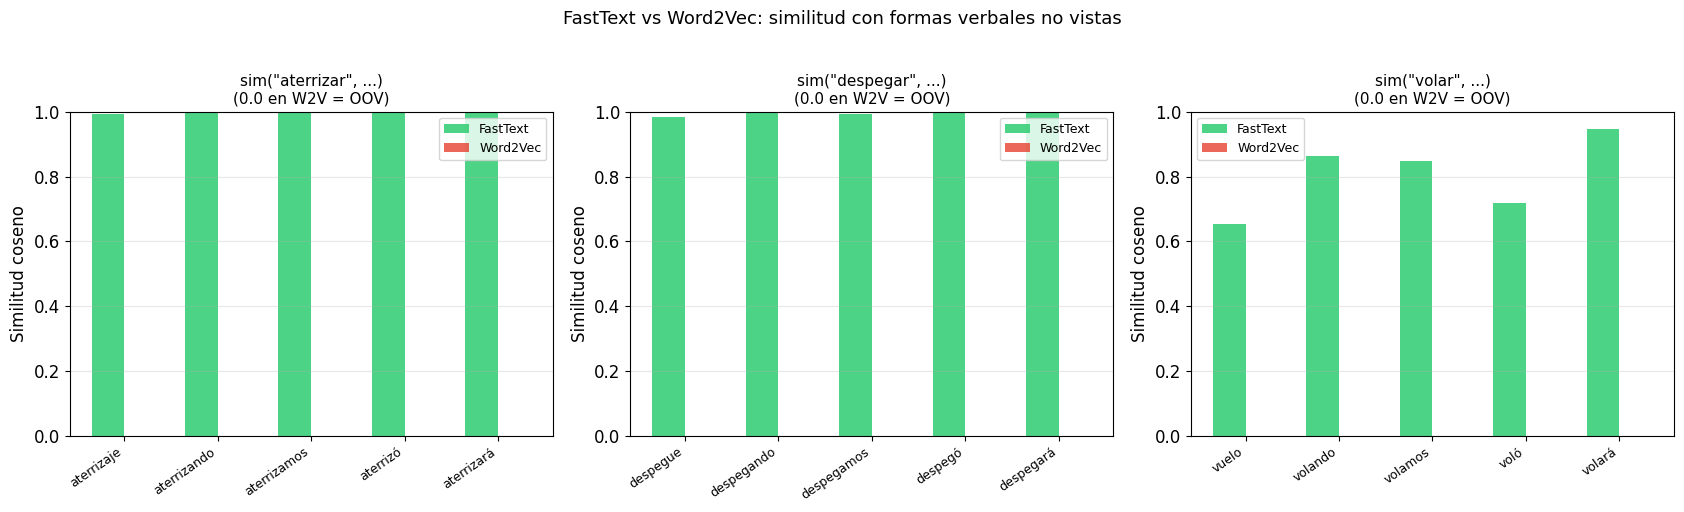

In [7]:
# FastText capta similitud entre formas morfológicas relacionadas
familias = {
    'aterrizar': ['aterrizaje', 'aterrizando', 'aterrizamos', 'aterrizó', 'aterrizará'],
    'despegar':  ['despegue', 'despegando', 'despegamos', 'despegó', 'despegará'],
    'volar':     ['vuelo', 'volando', 'volamos', 'voló', 'volará'],
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
for ax, (raiz, formas) in zip(axes, familias.items()):
    todas = [raiz] + formas
    # Similitudes con la raíz
    sim_ft, sim_w2v = [], []
    for f in formas:
        sim_ft.append(modelo_ft.wv.similarity(raiz, f))
        try:
            sim_w2v.append(modelo_w2v.wv.similarity(raiz, f))
        except KeyError:
            sim_w2v.append(0.0)  # OOV → similitud 0

    x = np.arange(len(formas))
    w = 0.35
    ax.bar(x - w/2, sim_ft,  w, label='FastText', color='#2ecc71', alpha=0.85)
    ax.bar(x + w/2, sim_w2v, w, label='Word2Vec', color='#e74c3c', alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(formas, rotation=35, ha='right', fontsize=9)
    ax.set_ylim(0, 1)
    ax.set_title(f'sim("{raiz}", ...)\n(0.0 en W2V = OOV)', fontsize=11)
    ax.set_ylabel('Similitud coseno')
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('FastText vs Word2Vec: similitud con formas verbales no vistas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Visualización PCA: FastText agrupa morfología

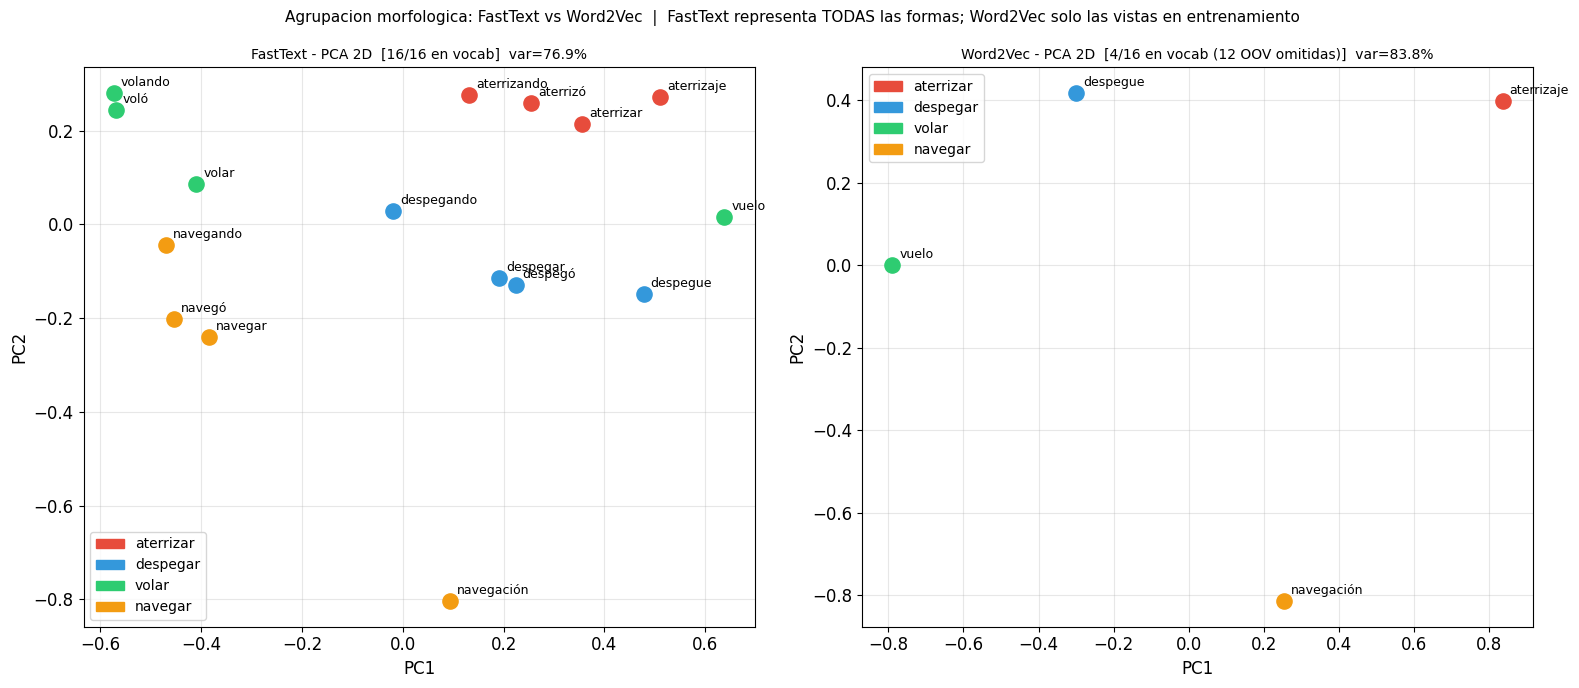

FastText agrupa formas de la misma familia morfologica.
Word2Vec solo puede representar las palabras que vio en entrenamiento.


In [8]:
# Mostrar como FastText coloca formas morfologicas cerca en el espacio
grupos_viz = {
    'aterrizar': ['aterrizar', 'aterrizaje', 'aterrizando', 'aterrizó'],
    'despegar':  ['despegar', 'despegue', 'despegando', 'despegó'],
    'volar':     ['volar', 'vuelo', 'volando', 'voló'],
    'navegar':   ['navegar', 'navegación', 'navegando', 'navegó'],
}
colores_grupos = {'aterrizar': '#e74c3c', 'despegar': '#3498db',
                  'volar': '#2ecc71', 'navegar': '#f39c12'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

for ax, modelo, titulo in [(ax1, modelo_ft, 'FastText'), (ax2, modelo_w2v, 'Word2Vec')]:
    palabras_plot, etiquetas_plot, colores_plot = [], [], []
    for grupo, formas in grupos_viz.items():
        for forma in formas:
            if forma in modelo.wv:
                palabras_plot.append(forma)
                etiquetas_plot.append(grupo)
                colores_plot.append(colores_grupos[grupo])

    n_total = sum(len(v) for v in grupos_viz.values())
    n_oov   = n_total - len(palabras_plot)
    oov_str = ' ({} OOV omitidas)'.format(n_oov) if n_oov else ''

    vecs   = np.array([modelo.wv[p] for p in palabras_plot])
    pca    = PCA(n_components=2, random_state=42)
    coords = pca.fit_transform(vecs)

    for i, (palabra, color) in enumerate(zip(palabras_plot, colores_plot)):
        ax.scatter(*coords[i], color=color, s=120, zorder=3)
        ax.annotate(palabra, coords[i], textcoords='offset points',
                    xytext=(5, 5), fontsize=9)

    leyenda = [mpatches.Patch(color=colores_grupos[g], label=g) for g in grupos_viz]
    ax.legend(handles=leyenda, fontsize=10)
    var_exp = pca.explained_variance_ratio_.sum()
    ax.set_title(
        '{} - PCA 2D  [{}/{} en vocab{}]  var={:.1%}'.format(
            titulo, len(palabras_plot), n_total, oov_str, var_exp),
        fontsize=10)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.3)

titulo_sup = ('Agrupacion morfologica: FastText vs Word2Vec  |  '
              'FastText representa TODAS las formas; Word2Vec solo las vistas en entrenamiento')
plt.suptitle(titulo_sup, fontsize=11)
plt.tight_layout()
plt.show()

print('FastText agrupa formas de la misma familia morfologica.')
print('Word2Vec solo puede representar las palabras que vio en entrenamiento.')


### 1.6 Resumen: Word2Vec vs FastText

| Característica | Word2Vec | FastText |
|----------------|----------|----------|
| Unidad básica | Palabra completa | N-gramas de caracteres |
| Palabras OOV | ❌ Error | ✅ Vector aproximado |
| Morfología | ❌ No capta | ✅ Sí capta |
| Velocidad entrenamiento | Rápida | Algo más lenta |
| Tamaño del modelo | Menor | Mayor (almacena n-gramas) |
| Ideal para | Vocabulario fijo, inglés | Morfología rica, idiomas nuevos |

**Cuándo usar FastText:** idiomas con morfología rica (español, alemán, árabe), dominios con neologismos frecuentes, texto con errores ortográficos.

<a id='2'></a>
## 2. Sentence-BERT: embeddings contextuales de frases

### 2.1 El problema: el orden importa

El promedio de word vectors (FastText/Word2Vec) produce **el mismo vector** sin importar el orden de las palabras.

In [28]:
# Demostración del problema con promedio de word vectors
def avg_embedding(frase, modelo_wv):
    words = [w for w in frase.lower().split() if w in modelo_wv]
    return np.mean([modelo_wv[w] for w in words], axis=0) if words else None

pares_problematicos = [
    ("el piloto controla el avión",
     "el piloto controla sus nervios"),
    ("el motor falla antes del despegue",
     "el motor no falla antes del despegue"),
    ("la torre de control habla al piloto",
     "el piloto habla sobe torres"),
]

print('Similitud coseno con PROMEDIO de word vectors (FastText):')
print('Dos frases con el mismo contenido pero distinto significado:')
print('=' * 70)
for f1, f2 in pares_problematicos:
    v1 = avg_embedding(f1, modelo_ft.wv)
    v2 = avg_embedding(f2, modelo_ft.wv)
    sim = cosine_similarity([v1], [v2])[0][0]
    print(f'\n  A: "{f1}"')
    print(f'  B: "{f2}"')
    print(f'  Similitud (avg FastText): {sim:.4f}  ← ¡Casi idénticas!')

print()
print('PROBLEMA: el promedio ignora el orden → mismo vector para frases con')
print('significados opuestos.')

Similitud coseno con PROMEDIO de word vectors (FastText):
Dos frases con el mismo contenido pero distinto significado:

  A: "el piloto controla el avión"
  B: "el piloto controla sus nervios"
  Similitud (avg FastText): 0.9873  ← ¡Casi idénticas!

  A: "el motor falla antes del despegue"
  B: "el motor no falla antes del despegue"
  Similitud (avg FastText): 1.0000  ← ¡Casi idénticas!

  A: "la torre de control habla al piloto"
  B: "el piloto habla sobe torres"
  Similitud (avg FastText): 0.9520  ← ¡Casi idénticas!

PROBLEMA: el promedio ignora el orden → mismo vector para frases con
significados opuestos.


### 2.2 Arquitectura de Sentence-BERT

**BERT** (Bidirectional Encoder Representations from Transformers, Devlin et al. 2018) procesa toda la frase con atención bidireccional → cada token recibe un vector **contextualizado**.

**Sentence-BERT** (Reimers & Gurevych, 2019) añade una capa de *pooling* sobre BERT para obtener un único vector por frase, entrenado con pérdidas de similitud semántica.

```
Frase: "el piloto aterriza el avión"
         ↓   tokenización
   [CLS] el piloto aterriza el avión [SEP]
         ↓   BERT (12 capas Transformer)
   h_CLS  h_el  h_piloto  h_aterriza  h_el  h_avión  h_SEP
         ↓   mean pooling
         vector de frase (768 dims) ← capture contexto y orden
```

El modelo que usaremos — `paraphrase-multilingual-MiniLM-L12-v2` — es multilingüe (50+ idiomas, incluido español), con vectores de **384 dimensiones**.

In [10]:
# Cargar el modelo (ya está en caché local, no descarga nada)
sbert = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print(f'Modelo cargado: paraphrase-multilingual-MiniLM-L12-v2')
print(f'Dimensión de embeddings: {sbert.get_sentence_embedding_dimension()}')
print(f'Idiomas soportados: 50+ (incluye español)')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6751.38it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modelo cargado: paraphrase-multilingual-MiniLM-L12-v2
Dimensión de embeddings: 384
Idiomas soportados: 50+ (incluye español)


### 2.3 Sentence-BERT sí capta el orden

In [11]:
print('Similitud coseno con Sentence-BERT vs promedio FastText:')
print('=' * 70)
for f1, f2 in pares_problematicos:
    # Sentence-BERT
    v_sbert = sbert.encode([f1, f2])
    sim_sbert = cosine_similarity([v_sbert[0]], [v_sbert[1]])[0][0]
    
    # Promedio FastText
    v1_ft = avg_embedding(f1, modelo_ft.wv)
    v2_ft = avg_embedding(f2, modelo_ft.wv)
    sim_ft = cosine_similarity([v1_ft], [v2_ft])[0][0]

    print(f'\n  A: "{f1}"')
    print(f'  B: "{f2}"')
    print(f'  avg FastText:   {sim_ft:.4f}')
    print(f'  Sentence-BERT:  {sim_sbert:.4f}  ← más diferenciado')

Similitud coseno con Sentence-BERT vs promedio FastText:

  A: "el piloto controla el avión"
  B: "el avión controla el piloto"
  avg FastText:   1.0000
  Sentence-BERT:  0.9788  ← más diferenciado

  A: "el motor falla antes del despegue"
  B: "el despegue falla antes del motor"
  avg FastText:   1.0000
  Sentence-BERT:  0.9611  ← más diferenciado

  A: "la torre de control guía al piloto"
  B: "el piloto guía a la torre de control"
  avg FastText:   0.9857
  Sentence-BERT:  0.9613  ← más diferenciado


### 2.4 Tareas de similitud semántica

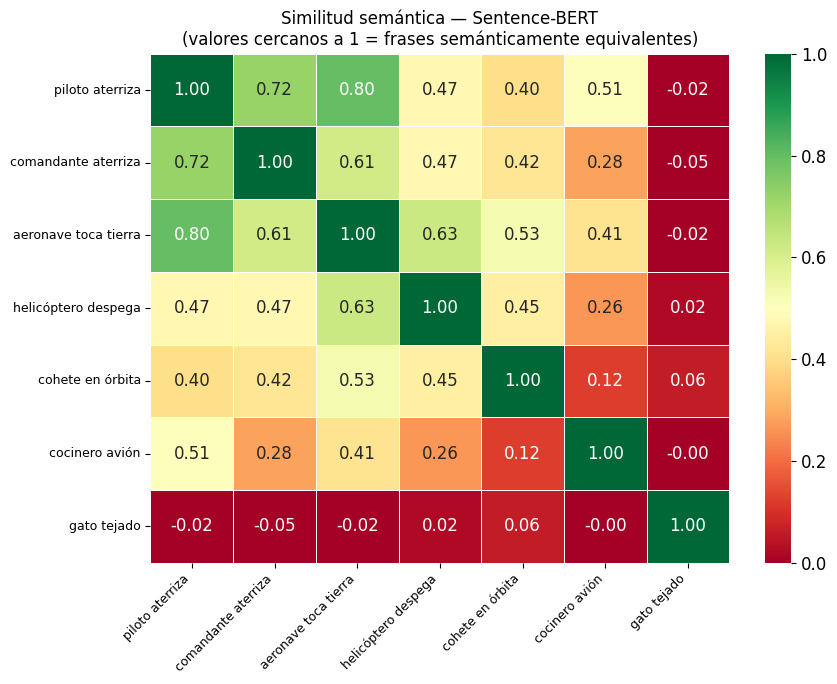

In [12]:
# Frases con distintos grados de similitud semántica
frases_ref = [
    "El piloto aterriza el avión en la pista principal.",
    "El comandante realiza el aterrizaje en la pista uno.",       # paráfrasis
    "La aeronave toca tierra en la zona de aterrizaje.",          # paráfrasis lejana
    "El helicóptero despega desde la plataforma offshore.",       # mismo dominio, otro tema
    "El cohete entra en órbita alrededor de la Tierra.",          # dominio aeroespacial
    "El cocinero prepara la cena para los pasajeros del avión.",  # relacionado pero distinto
    "El gato duerme en el tejado de la casa.",                    # no relacionado
]

embeddings = sbert.encode(frases_ref)
sim_matrix = cosine_similarity(embeddings)

etiquetas = [
    'piloto aterriza', 'comandante aterriza', 'aeronave toca tierra',
    'helicóptero despega', 'cohete en órbita', 'cocinero avión', 'gato tejado'
]

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(sim_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=0, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Similitud semántica — Sentence-BERT\n(valores cercanos a 1 = frases semánticamente equivalentes)', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

### 2.5 Búsqueda semántica

In [13]:
# Corpus de documentos técnicos
documentos = [
    "El sistema de piloto automático mantiene la altitud y el rumbo programados.",
    "El radar meteorológico detecta celdas de tormenta en la ruta del vuelo.",
    "El procedimiento de aproximación instrumental ILS guía el aterrizaje con niebla.",
    "El motor turbofán mezcla flujos de aire caliente y frío para generar empuje.",
    "El sistema TCAS genera alertas de tráfico para evitar colisiones en vuelo.",
    "La caja negra registra parámetros de vuelo y conversaciones de cabina.",
    "El transponder ADS-B emite la posición GPS del avión a los radares de control.",
    "El certificado de aeronavegabilidad acredita que la aeronave cumple la normativa.",
    "El sistema de gestión de vuelo FMS calcula la ruta óptima considerando el viento.",
    "La presurización de cabina mantiene la presión equivalente a 2400 metros de altitud.",
]

# Encodificar todos los documentos una sola vez
embeddings_docs = sbert.encode(documentos)

def busqueda_semantica(consulta, documentos, embeddings_docs, top_k=3):
    emb_consulta = sbert.encode([consulta])
    sims = cosine_similarity(emb_consulta, embeddings_docs)[0]
    indices = np.argsort(sims)[::-1][:top_k]
    print(f'Consulta: "{consulta}"')
    print(f'{"Rank":<6} {"Similitud":<12} Documento')
    print('-' * 80)
    for rank, idx in enumerate(indices, 1):
        print(f'  {rank}    {sims[idx]:.4f}      {documentos[idx]}')
    print()

consultas = [
    "¿Cómo evitar chocar con otro avión?",
    "sistema que vuela el avión solo",
    "registro de datos del vuelo",
]

for c in consultas:
    busqueda_semantica(c, documentos, embeddings_docs)

Consulta: "¿Cómo evitar chocar con otro avión?"
Rank   Similitud    Documento
--------------------------------------------------------------------------------
  1    0.4040      El procedimiento de aproximación instrumental ILS guía el aterrizaje con niebla.
  2    0.3980      El certificado de aeronavegabilidad acredita que la aeronave cumple la normativa.
  3    0.3513      El sistema TCAS genera alertas de tráfico para evitar colisiones en vuelo.

Consulta: "sistema que vuela el avión solo"
Rank   Similitud    Documento
--------------------------------------------------------------------------------
  1    0.5603      El sistema de piloto automático mantiene la altitud y el rumbo programados.
  2    0.5409      El procedimiento de aproximación instrumental ILS guía el aterrizaje con niebla.
  3    0.4850      El certificado de aeronavegabilidad acredita que la aeronave cumple la normativa.

Consulta: "registro de datos del vuelo"
Rank   Similitud    Documento
-----------------------

### 2.6 Visualización de Sentence Embeddings

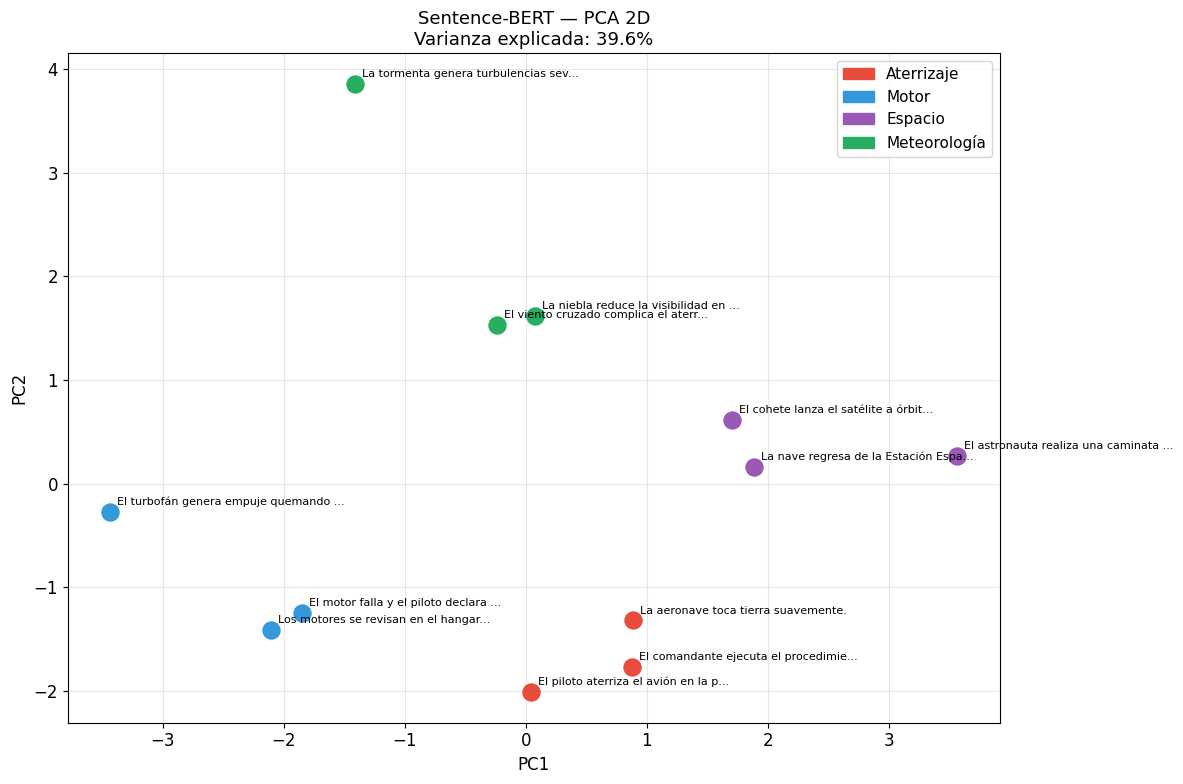

In [14]:
# Frases de diferentes temáticas
grupos_frases = {
    'Aterrizaje':  [
        "El piloto aterriza el avión en la pista.",
        "La aeronave toca tierra suavemente.",
        "El comandante ejecuta el procedimiento de aterrizaje.",
    ],
    'Motor':  [
        "El turbofán genera empuje quemando combustible.",
        "El motor falla y el piloto declara emergencia.",
        "Los motores se revisan en el hangar.",
    ],
    'Espacio': [
        "El cohete lanza el satélite a órbita.",
        "El astronauta realiza una caminata espacial.",
        "La nave regresa de la Estación Espacial Internacional.",
    ],
    'Meteorología': [
        "La tormenta genera turbulencias severas.",
        "La niebla reduce la visibilidad en el aeropuerto.",
        "El viento cruzado complica el aterrizaje.",
    ],
}

todas_frases, todas_etiquetas = [], []
colores_map = {'Aterrizaje': '#e74c3c', 'Motor': '#3498db',
               'Espacio': '#9b59b6', 'Meteorología': '#27ae60'}

for cat, frases_cat in grupos_frases.items():
    todas_frases.extend(frases_cat)
    todas_etiquetas.extend([cat] * len(frases_cat))

embs = sbert.encode(todas_frases)

# PCA a 2D
pca_s = PCA(n_components=2, random_state=42)
coords_s = pca_s.fit_transform(embs)

fig, ax = plt.subplots(figsize=(12, 8))
etiqueta_corta = lambda f: f[:35] + '...' if len(f) > 35 else f
for i, (frase, cat) in enumerate(zip(todas_frases, todas_etiquetas)):
    ax.scatter(*coords_s[i], color=colores_map[cat], s=150, zorder=3)
    ax.annotate(etiqueta_corta(frase), coords_s[i],
                textcoords='offset points', xytext=(5, 5), fontsize=8)

leyenda = [mpatches.Patch(color=colores_map[c], label=c) for c in grupos_frases]
ax.legend(handles=leyenda, fontsize=11)
ax.set_title(f'Sentence-BERT — PCA 2D\nVarianza explicada: {pca_s.explained_variance_ratio_.sum():.1%}', fontsize=13)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<a id='3'></a>
## 3. Chatbot Q&A con búsqueda semántica

Construimos un chatbot que responde preguntas buscando la pregunta más similar en una base de datos de Q&A mediante **Sentence-BERT**.

```
Pregunta usuario
      ↓  encode (Sentence-BERT)
Vector consulta  ──coseno──▶  Base de vectores Q&A
                                      ↓  argmax similitud
                              Respuesta del par más similar
                                      ↓  si sim < umbral
                              "No tengo información sobre eso"
```

In [15]:
# Base de datos Q&A sobre aviación y espacio
qa_database = [
    # Operaciones de vuelo
    {"pregunta": "¿Qué es el despegue asistido por catapulta?",
     "respuesta": "Es un método usado en portaaviones donde un sistema de vapor o electromágnetico lanza la aeronave a alta velocidad para alcanzar la velocidad de despegue en una pista muy corta."},
    {"pregunta": "¿Cuánto combustible consume un avión comercial?",
     "respuesta": "Un Boeing 737 consume unos 2.500 litros por hora. Un A380 puede consumir hasta 12.000 litros por hora. En términos de eficiencia, los aviones modernos consumen menos de 3 litros por pasajero cada 100 km."},
    {"pregunta": "¿Por qué los aviones vuelan tan alto?",
     "respuesta": "A gran altitud (10.000-12.000 m) el aire es menos denso, lo que reduce la resistencia aerodinámica y permite mayor eficiencia de combustible. Además se evitan las turbulencias atmosféricas de capas más bajas."},
    {"pregunta": "¿Qué es la velocidad de pérdida en un avión?",
     "respuesta": "Es la velocidad mínima a la que las alas generan suficiente sustentación. Por debajo de ella el ala 'entra en pérdida': el flujo de aire se separa y la sustentación cae bruscamente, lo que puede causar una situación peligrosa."},
    {"pregunta": "¿Cómo funciona el tren de aterrizaje?",
     "respuesta": "Es el sistema de ruedas que soporta el avión en tierra. Se retrae hidráulicamente tras el despegue para reducir la resistencia aerodinámica y se extiende antes de aterrizar. Incorpora amortiguadores para absorber el impacto."},
    # Navegación y sistemas
    {"pregunta": "¿Qué es el GPS y cómo lo usan los aviones?",
     "respuesta": "El GPS (Global Positioning System) usa señales de satélites para determinar la posición con precisión de metros. Los aviones lo integran en el FMS (Flight Management System) para seguir rutas programadas y ejecutar aproximaciones de precisión."},
    {"pregunta": "¿Qué hace el piloto automático?",
     "respuesta": "El piloto automático controla automáticamente actitud, altitud, rumbo y velocidad del avión según los parámetros programados. No sustituye al piloto: los pilotos supervisan el sistema y están siempre disponibles para tomar el control manual."},
    {"pregunta": "¿Qué es el ILS?",
     "respuesta": "El ILS (Instrument Landing System) es un sistema de radio que guía al avión en la aproximación final mediante dos señales: una horizontal (localizador) y una vertical (senda de planeo). Permite aterrizar con visibilidad casi nula."},
    {"pregunta": "¿Para qué sirve el transponder?",
     "respuesta": "El transponder emite un código de identificación y la altitud del avión en respuesta a los radares de control. El modo S y ADS-B añaden posición GPS, velocidad e identificación, permitiendo a los controladores ver cada avión en tiempo real."},
    {"pregunta": "¿Qué es el TCAS?",
     "respuesta": "El TCAS (Traffic Collision Avoidance System) es un sistema embarcado que detecta otros aviones con transponder y emite alertas de tráfico (TA) y resoluciones de maniobra (RA) para evitar colisiones, independientemente del control en tierra."},
    # Meteorología
    {"pregunta": "¿Qué son las turbulencias?",
     "respuesta": "Las turbulencias son variaciones bruscas de velocidad y dirección del aire. Pueden deberse a tormentas, corrientes de chorro, terreno montañoso o aire claro (CAT). Son incómodas pero rara vez peligrosas en aviones modernos."},
    {"pregunta": "¿Cuánto afecta el viento al vuelo?",
     "respuesta": "El viento de cola acelera el avión y reduce el consumo de combustible. El viento de cara lo ralentiza. El viento cruzado dificulta el aterrizaje; todos los aviones tienen un límite de viento cruzado certificado que no debe superarse."},
    {"pregunta": "¿Por qué los rayos no derriban aviones?",
     "respuesta": "Los aviones están diseñados como jaulas de Faraday: la estructura metálica conduce la corriente alrededor de la cabina. Los rayos los impactan varias veces al año sin consecuencias graves. Los sistemas electrónicos tienen protección específica."},
    # Espacio
    {"pregunta": "¿Cómo funciona un motor cohete?",
     "respuesta": "Un motor cohete combina combustible y oxidante para generar gases a alta presión que salen por la tobera a gran velocidad. Por la tercera ley de Newton, la expulsión de gases genera el empuje. A diferencia de los reactores, no necesitan aire exterior."},
    {"pregunta": "¿Qué es una órbita geoestacionaria?",
     "respuesta": "Es una órbita circular a 35.786 km de altitud en el ecuador, donde el período orbital (24 horas) coincide con la rotación de la Tierra. El satélite aparece fijo en el cielo, ideal para comunicaciones y meteorología."},
    {"pregunta": "¿Qué es la velocidad de escape?",
     "respuesta": "Es la velocidad mínima (~11,2 km/s en la Tierra) que un objeto necesita para escapar del campo gravitatorio sin propulsión adicional. Los cohetes no necesitan alcanzarla de golpe: usan propulsión continua para llegar a órbita."},
    {"pregunta": "¿Cómo protegen a los astronautas de la radiación espacial?",
     "respuesta": "La ISS orbita dentro de los cinturones de Van Allen, que ofrecen cierta protección. Los trajes espaciales tienen blindaje limitado. Para misiones largas (Luna, Marte) se diseñan refugios con agua o polietileno como absorbentes de radiación."},
    # Seguridad
    {"pregunta": "¿Qué es la caja negra?",
     "respuesta": "Son dos dispositivos: el FDR (registrador de parámetros de vuelo) y el CVR (registrador de conversaciones de cabina). Resisten impactos, fuego y presión. Son de color naranja brillante, no negro, para facilitar su localización."},
    {"pregunta": "¿Por qué los aviones son tan seguros?",
     "respuesta": "La aviación comercial tiene una tasa de accidentes de 0,07 por millón de vuelos. Se debe a redundancia de sistemas, mantenimiento riguroso, entrenamiento continuo de pilotos, certificación estricta y análisis exhaustivo de todos los incidentes."},
    {"pregunta": "¿Puede un avión volar con un solo motor?",
     "respuesta": "Sí. Los aviones comerciales están certificados para volar y aterrizar con un motor inoperativo (ETOPS para bimotor). Los procedimientos de motor apagado son parte del entrenamiento estándar de pilotos."},
]

print(f'Base de datos Q&A: {len(qa_database)} pares pregunta-respuesta')

# Encodificar todas las preguntas de la base de datos
preguntas_bd = [item['pregunta'] for item in qa_database]
respuestas_bd = [item['respuesta'] for item in qa_database]
embeddings_bd = sbert.encode(preguntas_bd)

print('Embeddings de la base de datos precalculados.')

Base de datos Q&A: 20 pares pregunta-respuesta
Embeddings de la base de datos precalculados.


### 3.1 Núcleo del chatbot

In [16]:
def chatbot_qa(consulta, umbral=0.45, top_k=3, verbose=False):
    """
    Busca la respuesta más relevante para una consulta en la base de datos Q&A.
    
    - umbral: similitud mínima para dar una respuesta (si no se supera → "no sé")
    - top_k:  cuántos candidatos mostrar en modo verbose
    """
    emb_consulta = sbert.encode([consulta])
    similitudes  = cosine_similarity(emb_consulta, embeddings_bd)[0]
    indices_top  = np.argsort(similitudes)[::-1][:top_k]
    mejor_idx    = indices_top[0]
    mejor_sim    = similitudes[mejor_idx]

    if verbose:
        print(f'Top {top_k} preguntas más similares:')
        for i, idx in enumerate(indices_top, 1):
            print(f'  {i}. [{similitudes[idx]:.3f}] {preguntas_bd[idx]}')
        print()

    if mejor_sim < umbral:
        return (f"Lo siento, no tengo información suficiente sobre eso "
                f"(similitud máxima: {mejor_sim:.3f}, umbral: {umbral}).\n"
                f"Prueba a reformular la pregunta."), mejor_sim

    return respuestas_bd[mejor_idx], mejor_sim


def chat(consulta, verbose=False):
    respuesta, sim = chatbot_qa(consulta, verbose=verbose)
    print(f'Pregunta: {consulta}')
    print(f'[similitud: {sim:.3f}]')
    print(f'Respuesta: {respuesta}')
    print('-' * 75)

print('Chatbot listo.')

Chatbot listo.


### 3.2 Pruebas del chatbot

In [17]:
# --- Preguntas directas (muy similares a las de la BD) ---
print('CASO 1: Preguntas directas\n')
chat("¿Qué es el piloto automático?")
chat("¿Qué hace la caja negra en un avión?")
chat("¿Cómo funciona el motor de un cohete?")

CASO 1: Preguntas directas

Pregunta: ¿Qué es el piloto automático?
[similitud: 0.947]
Respuesta: El piloto automático controla automáticamente actitud, altitud, rumbo y velocidad del avión según los parámetros programados. No sustituye al piloto: los pilotos supervisan el sistema y están siempre disponibles para tomar el control manual.
---------------------------------------------------------------------------
Pregunta: ¿Qué hace la caja negra en un avión?
[similitud: 0.816]
Respuesta: Son dos dispositivos: el FDR (registrador de parámetros de vuelo) y el CVR (registrador de conversaciones de cabina). Resisten impactos, fuego y presión. Son de color naranja brillante, no negro, para facilitar su localización.
---------------------------------------------------------------------------
Pregunta: ¿Cómo funciona el motor de un cohete?
[similitud: 0.989]
Respuesta: Un motor cohete combina combustible y oxidante para generar gases a alta presión que salen por la tobera a gran velocidad. Po

In [18]:
# --- Paráfrasis (misma intención, palabras distintas) ---
print('CASO 2: Paráfrasis — distintas palabras, misma intención\n')
chat("¿Por qué vuelan tan arriba los aviones?")
chat("¿Pueden seguir volando si falla un motor?")
chat("¿Qué sistema evita que dos aviones colisionen?")

CASO 2: Paráfrasis — distintas palabras, misma intención

Pregunta: ¿Por qué vuelan tan arriba los aviones?
[similitud: 0.947]
Respuesta: A gran altitud (10.000-12.000 m) el aire es menos denso, lo que reduce la resistencia aerodinámica y permite mayor eficiencia de combustible. Además se evitan las turbulencias atmosféricas de capas más bajas.
---------------------------------------------------------------------------
Pregunta: ¿Pueden seguir volando si falla un motor?
[similitud: 0.767]
Respuesta: Sí. Los aviones comerciales están certificados para volar y aterrizar con un motor inoperativo (ETOPS para bimotor). Los procedimientos de motor apagado son parte del entrenamiento estándar de pilotos.
---------------------------------------------------------------------------
Pregunta: ¿Qué sistema evita que dos aviones colisionen?
[similitud: 0.647]
Respuesta: Sí. Los aviones comerciales están certificados para volar y aterrizar con un motor inoperativo (ETOPS para bimotor). Los procedimi

In [19]:
# --- Preguntas con errores ortográficos ---
print('CASO 3: Errores tipográficos y coloquialismos\n')
chat("komo funciona el gps en un avion")
chat("rayos en los aviones, son peligrosos?")
chat("cuanto gasoil usa un 737")

CASO 3: Errores tipográficos y coloquialismos

Pregunta: komo funciona el gps en un avion
[similitud: 0.669]
Respuesta: El GPS (Global Positioning System) usa señales de satélites para determinar la posición con precisión de metros. Los aviones lo integran en el FMS (Flight Management System) para seguir rutas programadas y ejecutar aproximaciones de precisión.
---------------------------------------------------------------------------
Pregunta: rayos en los aviones, son peligrosos?
[similitud: 0.741]
Respuesta: Los aviones están diseñados como jaulas de Faraday: la estructura metálica conduce la corriente alrededor de la cabina. Los rayos los impactan varias veces al año sin consecuencias graves. Los sistemas electrónicos tienen protección específica.
---------------------------------------------------------------------------
Pregunta: cuanto gasoil usa un 737
[similitud: 0.715]
Respuesta: Un Boeing 737 consume unos 2.500 litros por hora. Un A380 puede consumir hasta 12.000 litros por

In [20]:
# --- Preguntas fuera del dominio (debe rechazar) ---
print('CASO 4: Preguntas fuera del dominio (debe indicar que no sabe)\n')
chat("¿Cuál es la mejor receta de paella?")
chat("¿Quién ganó el mundial de fútbol de 2022?")
chat("¿Cómo se programa en Python?")

CASO 4: Preguntas fuera del dominio (debe indicar que no sabe)

Pregunta: ¿Cuál es la mejor receta de paella?
[similitud: 0.108]
Respuesta: Lo siento, no tengo información suficiente sobre eso (similitud máxima: 0.108, umbral: 0.45).
Prueba a reformular la pregunta.
---------------------------------------------------------------------------
Pregunta: ¿Quién ganó el mundial de fútbol de 2022?
[similitud: 0.163]
Respuesta: Lo siento, no tengo información suficiente sobre eso (similitud máxima: 0.163, umbral: 0.45).
Prueba a reformular la pregunta.
---------------------------------------------------------------------------
Pregunta: ¿Cómo se programa en Python?
[similitud: 0.224]
Respuesta: Lo siento, no tengo información suficiente sobre eso (similitud máxima: 0.224, umbral: 0.45).
Prueba a reformular la pregunta.
---------------------------------------------------------------------------


In [21]:
# --- Verbose: ver los candidatos antes de responder ---
print('CASO 5: Modo verbose — candidatos internos del sistema\n')
chat("sistema de aterrizaje cuando no se ve nada", verbose=True)

CASO 5: Modo verbose — candidatos internos del sistema

Top 3 preguntas más similares:
  1. [0.614] ¿Cómo funciona el tren de aterrizaje?
  2. [0.563] ¿Por qué los aviones vuelan tan alto?
  3. [0.549] ¿Puede un avión volar con un solo motor?

Pregunta: sistema de aterrizaje cuando no se ve nada
[similitud: 0.614]
Respuesta: Es el sistema de ruedas que soporta el avión en tierra. Se retrae hidráulicamente tras el despegue para reducir la resistencia aerodinámica y se extiende antes de aterrizar. Incorpora amortiguadores para absorber el impacto.
---------------------------------------------------------------------------


### 3.3 Análisis del umbral de confianza

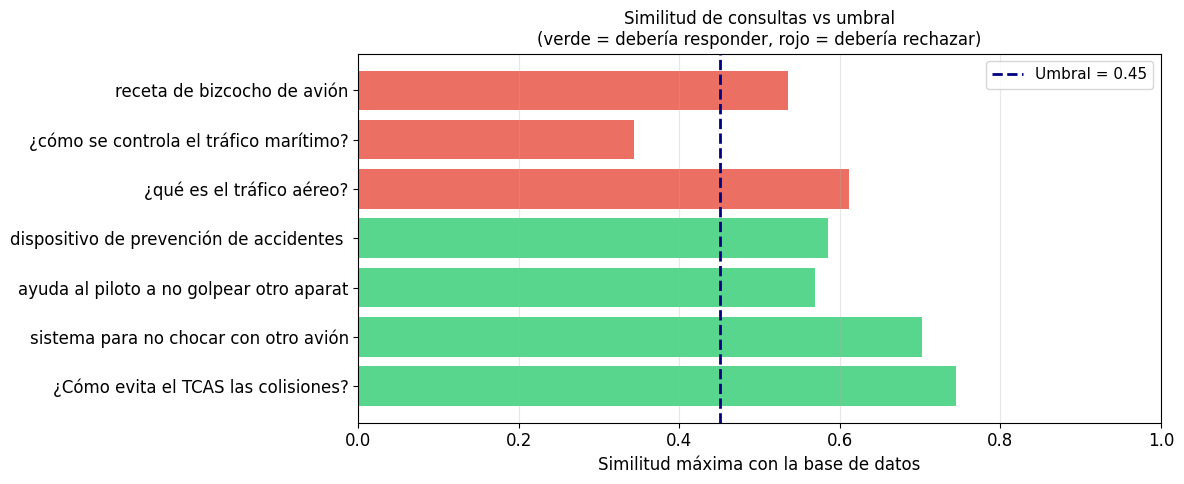

El umbral separa consultas dentro del dominio de las que no lo están.
Un umbral demasiado bajo genera respuestas inventadas (hallucination).
Un umbral demasiado alto rechaza preguntas legítimas reformuladas.


In [22]:
# Evaluar el efecto del umbral de similitud
consultas_test = [
    # (pregunta, ¿debería responder?)
    ("¿Cómo evita el TCAS las colisiones?",                True),
    ("sistema para no chocar con otro avión",              True),
    ("ayuda al piloto a no golpear otro aparato",          True),
    ("dispositivo de prevención de accidentes aéreos",     True),
    ("¿qué es el tráfico aéreo?",                          False),   # borderline
    ("¿cómo se controla el tráfico marítimo?",             False),   # fuera de dominio
    ("receta de bizcocho de avión",                        False),   # claramente fuera
]

umbrales = np.arange(0.2, 0.75, 0.05)
resultados = []
for consulta, debe_responder in consultas_test:
    emb = sbert.encode([consulta])
    sims = cosine_similarity(emb, embeddings_bd)[0]
    mejor_sim = sims.max()
    resultados.append({'consulta': consulta[:40], 'sim': mejor_sim, 'debe': debe_responder})

df_res = pd.DataFrame(resultados)

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#2ecc71' if r else '#e74c3c' for r in df_res['debe']]
bars = ax.barh(df_res['consulta'], df_res['sim'], color=colors, alpha=0.8)
ax.axvline(x=0.45, color='navy', linestyle='--', linewidth=2, label='Umbral = 0.45')
ax.set_xlabel('Similitud máxima con la base de datos')
ax.set_title('Similitud de consultas vs umbral\n(verde = debería responder, rojo = debería rechazar)', fontsize=12)
ax.set_xlim(0, 1)
ax.legend(fontsize=11)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print('El umbral separa consultas dentro del dominio de las que no lo están.')
print('Un umbral demasiado bajo genera respuestas inventadas (hallucination).')
print('Un umbral demasiado alto rechaza preguntas legítimas reformuladas.')

### 3.4 Sesión de chat interactiva

In [23]:
# Descomenta la celda para una sesión interactiva en el notebook

# print('Chatbot de Aviación y Espacio')
# print('Escribe "salir" para terminar.\n')
# while True:
#     pregunta = input('Tú: ').strip()
#     if pregunta.lower() in ('salir', 'exit', 'quit', ''):
#         print('¡Hasta luego!')
#         break
#     respuesta, sim = chatbot_qa(pregunta)
#     print(f'Bot [{sim:.2f}]: {respuesta}\n')

print('Descomenta el bloque anterior para iniciar la sesión interactiva.')

Descomenta el bloque anterior para iniciar la sesión interactiva.


## Resumen final

| Técnica | Representación | OOV | Orden | Contexto | Uso típico |
|---------|---------------|-----|-------|----------|------------|
| **One-Hot** | Dispersa (N dims) | ❌ | ❌ | ❌ | Línea base |
| **Word2Vec** | Densa (50–300 dims) | ❌ | ❌ | Ventana local | NLP clásico |
| **FastText** | Densa + n-gramas | ✅ | ❌ | Ventana local | Morfología, OOV |
| **Sentence-BERT** | Densa (384–768 dims) | ✅ | ✅ | Global (Transformer) | Similitud, búsqueda, chatbot |
| **GPT/LLMs** | Densa + generativa | ✅ | ✅ | Global + generativo | Generación de texto |

### El chatbot Q&A en producción
Para un sistema real se añadirían:
- **FAISS** o **ChromaDB**: índice vectorial para millones de documentos en milisegundos
- **Re-ranking**: un modelo más preciso (cross-encoder) reordena los top-K candidatos
- **RAG** (Retrieval-Augmented Generation): el LLM genera la respuesta a partir de los documentos recuperados